# P13 - Evaluation des modeles ML

Benchmark des modeles candidats sur les 3 cibles du projet.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

if Path('/app/src').exists():
    sys.path.insert(0, '/app/src')
else:
    sys.path.insert(0, '../../src')

from p13.db import read_sql
from p13.ml.features import ALL_TARGETS, FEATURE_COLUMNS
from p13.ml.train import get_model_candidates

In [2]:
df = read_sql('SELECT * FROM ml_dataset_commune WHERE nb_eleves_maternelle IS NOT NULL')
df = df.dropna(subset=FEATURE_COLUMNS + ALL_TARGETS).copy()

if len(df) < 20:
    raise ValueError(f'Dataset trop petit pour benchmark robuste: {len(df)} lignes')

df.shape

(688, 17)

In [3]:
def metrics(y_true, y_pred):
    mape_mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mape_mask] - y_pred[mape_mask]) / y_true[mape_mask])) * 100) if mape_mask.any() else 0.0
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'mape': mape
    }

In [4]:
rows = []
X = df[FEATURE_COLUMNS].values

for target in ALL_TARGETS:
    y = df[target].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    for model_name, model in get_model_candidates().items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        m = metrics(y_test, y_pred)
        rows.append({'target': target, 'model': model_name, **m})

results = pd.DataFrame(rows).sort_values(['target', 'r2'], ascending=[True, False])
results

,target,model,rmse,mae,r2,mape
11,nb_classes,gradient_boosting,7.723191,2.750794,0.995485,8.336918
10,nb_classes,random_forest,7.746429,2.750697,0.995458,8.285821
8,nb_classes,linear_regression,7.926863,3.473632,0.995244,16.133245
9,nb_classes,ridge,8.027885,3.516986,0.995122,16.492199
7,nb_eleves_elementaire,gradient_boosting,101.592042,42.118586,0.995841,8.898120
6,nb_eleves_elementaire,random_forest,102.169330,42.206123,0.995793,8.941682
4,nb_eleves_elementaire,linear_regression,104.210148,48.651679,0.995624,13.192006
5,nb_eleves_elementaire,ridge,105.583754,48.628412,0.995507,13.162026
3,nb_eleves_maternelle,gradient_boosting,48.823436,23.527545,0.997969,10.559866
2,nb_eleves_maternelle,random_forest,49.308784,23.492277,0.997929,10.490748


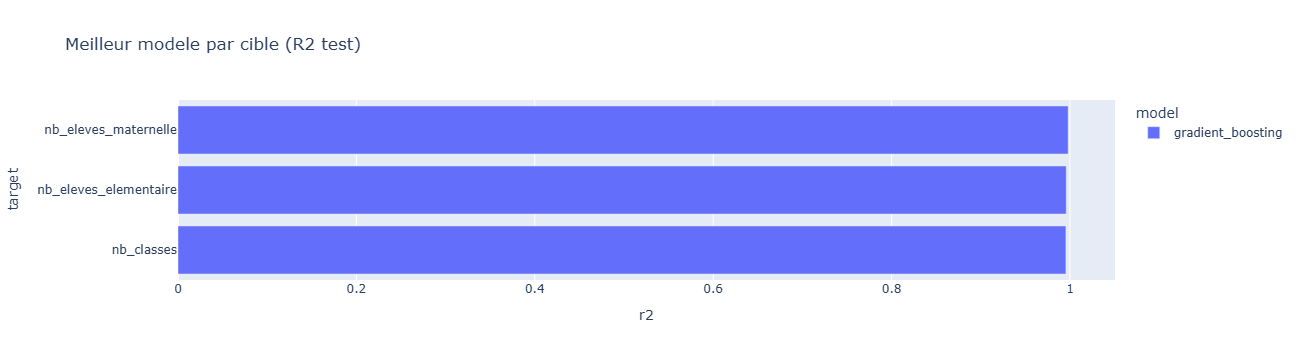

,target,model,rmse,mae,r2,mape
11,nb_classes,gradient_boosting,7.723191,2.750794,0.995485,8.336918
7,nb_eleves_elementaire,gradient_boosting,101.592042,42.118586,0.995841,8.898120
3,nb_eleves_maternelle,gradient_boosting,48.823436,23.527545,0.997969,10.559866


In [5]:
best = results.loc[results.groupby('target')['r2'].idxmax()].copy()
best = best.sort_values('r2', ascending=True)

fig = px.bar(
    best,
    x='r2',
    y='target',
    color='model',
    orientation='h',
    title='Meilleur modele par cible (R2 test)'
)
fig.show()
best

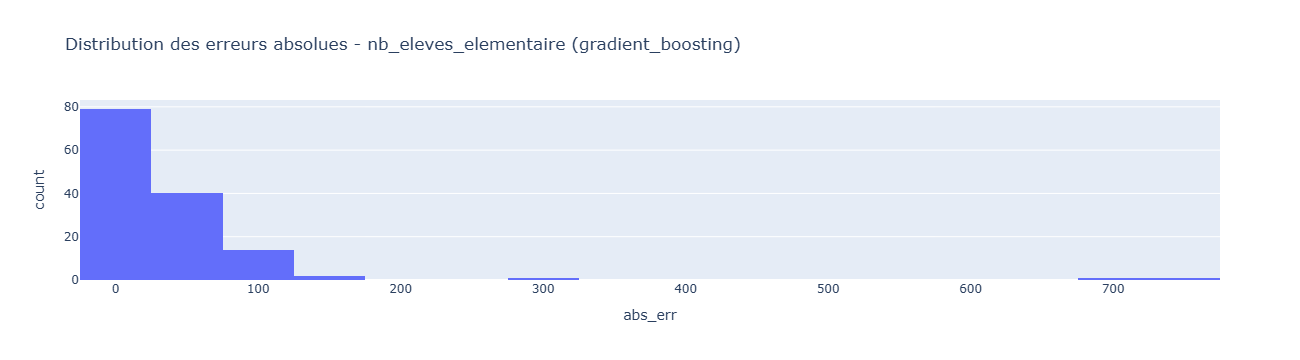

,y_true,y_pred,abs_err
count,138.000000,138.000000,138.000000
mean,570.478261,555.659102,42.118586
std,1580.980465,1494.326019,92.786607
min,38.000000,49.015631,0.289863
25%,145.000000,146.730658,5.601366
50%,292.000000,288.817072,16.893372
75%,491.750000,479.650387,46.410926
max,11200.000000,10429.589948,770.410052


In [6]:
target_focus = 'nb_eleves_elementaire'
winner = results[results['target'] == target_focus].sort_values('r2', ascending=False).iloc[0]['model']

model = get_model_candidates()[winner]
y = df[target_focus].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

errors = pd.DataFrame({'y_true': y_test, 'y_pred': pred})
errors['abs_err'] = (errors['y_true'] - errors['y_pred']).abs()

fig_err = px.histogram(errors, x='abs_err', nbins=30, title=f'Distribution des erreurs absolues - {target_focus} ({winner})')
fig_err.show()
errors.describe()